#### **1. Linear Regression, Outliers, and Regularization**

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

indexno = 220525  

rng = np.random.default_rng(indexno)
X = rng.uniform(-3, 3, size=(160, 1))
y = 2.5 + 1.8 * X[:, 0] + rng.normal(0, 0.8, size=160)

# Add large errors to 12 observations.
outlier_idx = rng.choice(len(y), size=12, replace=False)
y[outlier_idx] += rng.uniform(10, 15, size=12)

**Question 1**  
Explain why Ordinary Least Squares (OLS) estimation is particularly sensitive to severe vertical outliers in y. Reference the squared loss function $J(\mathbf{w}) = \frac{1}{2N} \sum_{i} (y_i - \mathbf{w}^T\mathbf{x}_i)^2$ in your answer.

---

OLS gets w by minimizing $J(\mathbf{w}) = \frac{1}{2N} \sum_{i} (y_i - \mathbf{w}^T\mathbf{x}_i)^2$. The sensitivity to outliers direclty comes from squars of residuals. 
A residual of an inliner is very small like $\sigma$ = 0.7, so the $\sigma^2$ = 0.49.
But residual of an outlier is a more like 10 - 15 and the squared error is 100 - 255. Therefore vertical outlier contribute strongly to the $J(\mathbf{w})$. 
When trying to minimize, OLS pulls line towards the outliers moving line towards it while inlier residuals grow slightly causing disorting the true line.

---
**Question 2**

Fit an ordinary least-squares (OLS) model to the generated data. Report its fitted intercept ($w_0$), slope coefficient ($w_1$), training Mean Squared Error ($\text{MSE}_{\text{train}}$), and test Mean Squared Error ($\text{MSE}_{\text{test}}$). Provide a scatter plot showing the data points along with the fitted regression line.

---

Intercept (w0) = 3.2618
Slope     (w1) = 1.8219
MSE train      = 10.1153
MSE test       = 13.2251


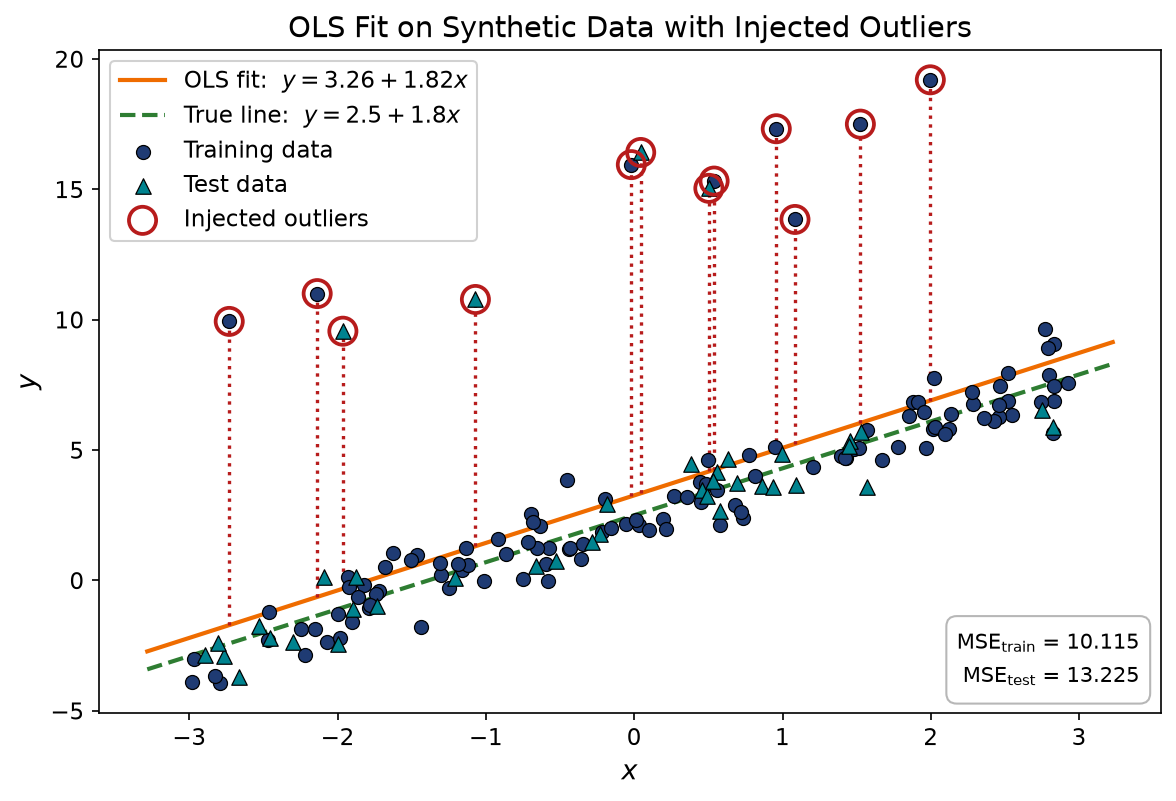

In [15]:
# Train/test split + OLS fit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)  

ols = LinearRegression()
ols.fit(X_train, y_train)

w0 = ols.intercept_
w1 = ols.coef_[0]
mse_train = mean_squared_error(y_train, ols.predict(X_train))
mse_test  = mean_squared_error(y_test,  ols.predict(X_test))

print(f"Intercept (w0) = {w0:.4f}")
print(f"Slope     (w1) = {w1:.4f}")
print(f"MSE train      = {mse_train:.4f}")
print(f"MSE test       = {mse_test:.4f}")

Xf, X_tr, X_te = (np.asarray(a).ravel() for a in (X, X_train, X_test))
y_f, y_tr, y_te = (np.asarray(a).ravel() for a in (y, y_train, y_test))

x_line = np.linspace(Xf.min() - 0.3, Xf.max() + 0.3, 200)

fig, ax = plt.subplots(figsize=(8, 5.5))

# Candidate lines
ax.plot(x_line, w0 + w1 * x_line, color='#ef6c00', linewidth=2,
        label=rf'OLS fit:  $y = {w0:.2f} + {w1:.2f}x$')
ax.plot(x_line, 2.5 + 1.8 * x_line, color='#2e7d32', linewidth=2, linestyle='--',
        label=r'True line:  $y = 2.5 + 1.8x$')

# Data
ax.scatter(X_tr, y_tr, s=45, color='#1f3b73', zorder=3,
           edgecolor='black', linewidth=0.6, label='Training data')
ax.scatter(X_te, y_te, s=55, marker='^', color='#00838f', zorder=3,
           edgecolor='black', linewidth=0.6, label='Test data')
ax.scatter(Xf[outlier_idx], y_f[outlier_idx], s=170, facecolors='none',
           edgecolors='#b71c1c', linewidth=1.8, zorder=4,
           label='Injected outliers')

# Residual of each outlier against the OLS fit
for i in np.atleast_1d(outlier_idx):
    ax.vlines(Xf[i], w0 + w1 * Xf[i], y_f[i],
              color='#b71c1c', linestyle=':', linewidth=1.6, zorder=2)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('OLS Fit on Synthetic Data with Injected Outliers')
ax.annotate(rf'MSE$_\mathrm{{train}}$ = {mse_train:.3f}' '\n'
            rf'MSE$_\mathrm{{test}}$ = {mse_test:.3f}',
            xy=(0.98, 0.03), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=10, linespacing=1.6,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#b0b0b0', alpha=0.9))
ax.legend(framealpha=0.9, loc='upper left')

plt.tight_layout()
plt.savefig('figures/ols_fit_outliers.png', bbox_inches='tight')
plt.show()

---
**Question 3**


---
